In [12]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks() 

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.2/8062.4 GB disk)


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="API")
project = rf.workspace("work-cni0k").project("oil-ujwyl-fwgbd")
version = project.version(3)
dataset = version.download("yolov8") 

loading Roboflow workspace...
loading Roboflow project...


In [14]:
import yaml
import os

# --- CHANGE 'YOUR_DATASET_NAME' TO YOUR UPLOADED DATASET FOLDER NAME IN KAGGLE ---
# You can find the exact path by clicking the 'Copy File Path' button on your data.yaml in the Kaggle right-sidebar.
dataset_dir = '/kaggle/working/Oil-3'

# Create a fixed dataset configuration dictionary
data_config = {
    'train': os.path.join(dataset_dir, 'train', 'images'),
    'val': os.path.join(dataset_dir, 'valid', 'images'),
    'test': os.path.join(dataset_dir, 'test', 'images'),
    'nc': 1,
    'names': ['oil spill detection - v2 resize-640']
}

# Save it to Kaggle's working directory 
fixed_yaml_path = '/kaggle/working/data.yaml'
with open(fixed_yaml_path, 'w') as outfile:
    yaml.dump(data_config, outfile, default_flow_style=False)

print(f"Fixed data.yaml saved to {fixed_yaml_path}")


Fixed data.yaml saved to /kaggle/working/data.yaml


In [16]:
from ultralytics import YOLO

# Load the YOLOv8 Extra-Large model (yolov8x.pt) for Maximum Accuracy.
# Alternatively, you can use 'yolov8m.pt' (Medium) or 'yolov8l.pt' (Large)
model = YOLO('yolov8s.pt')

# Train the model
results = model.train(
    data=fixed_yaml_path,     # Use the fixed yaml file we just created
    epochs=100,                # Number of full passes through the dataset
    imgsz=640,                # Image size (Dataset explicitly says v2 resize-640)
    batch=8,                  # Reduced to 8 since the extra-large model needs more GPU RAM
    device=0,                 # 0 means use the Kaggle GPU
    project='/kaggle/working/runs', 
    name='oil_spill_model',         
    patience=10               # Optional: Stop early if no improvement after 10 epochs
)

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=oil_spill_model3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspect

In [17]:
# Validate the model
metrics = model.val()

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1681.8±422.1 MB/s, size: 58.4 KB)
val: Scanning /kaggle/working/Oil-3/valid/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 62.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.3it/s 3.6s0.2s
                   all        180        276      0.706      0.686      0.732      0.387
Speed: 1.9ms preprocess, 10.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
mAP50-95: 0.3868693739896062
mAP50: 0.7315652264043832


In [19]:
import glob

# Get a list of all test images
test_dir = os.path.join(dataset_dir, 'test', 'images')
test_images = glob.glob(f"{test_dir}/*.jpg")

# Run predictions on the test images
predict_results = model.predict(
    source=test_dir, 
    save=True, 
    conf=0.25  # Confidence Threshold (Filters out bounding boxes below 25% confidence)
)


image 1/89 /kaggle/working/Oil-3/test/images/USR_shadow_0007_fake_png_jpg.rf.6a3924ce06fe68c1246e601d35fde6b5.jpg: 640x640 1 oil spill detection - v2 resize-640, 16.3ms
image 2/89 /kaggle/working/Oil-3/test/images/USR_shadow_0010_fake_png_jpg.rf.2722247251dbd47f4c9d7b4718a55c5d.jpg: 640x640 2 oil spill detection - v2 resize-640s, 16.1ms
image 3/89 /kaggle/working/Oil-3/test/images/USR_shadow_0051_fake_png_jpg.rf.19396c8fb1ff0d1c723b0145a9a028b7.jpg: 640x640 2 oil spill detection - v2 resize-640s, 16.1ms
image 4/89 /kaggle/working/Oil-3/test/images/USR_shadow_0087_fake_png_jpg.rf.f2af9a51629c083eee48f9e16a7c788b.jpg: 640x640 4 oil spill detection - v2 resize-640s, 16.1ms
image 5/89 /kaggle/working/Oil-3/test/images/USR_shadow_0162_fake_png_jpg.rf.95c55805298587260db087d8eebde677.jpg: 640x640 4 oil spill detection - v2 resize-640s, 16.1ms
image 6/89 /kaggle/working/Oil-3/test/images/USR_shadow_0167_fake_png_jpg.rf.0573918124654828bc9ada81bcb140b0.jpg: 640x640 1 oil spill detection - v2 

Found 89 images in /kaggle/working/runs/detect/predict7


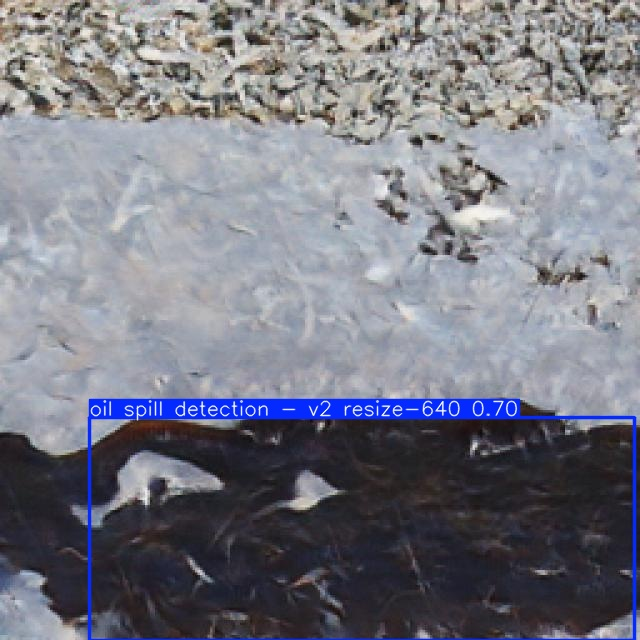

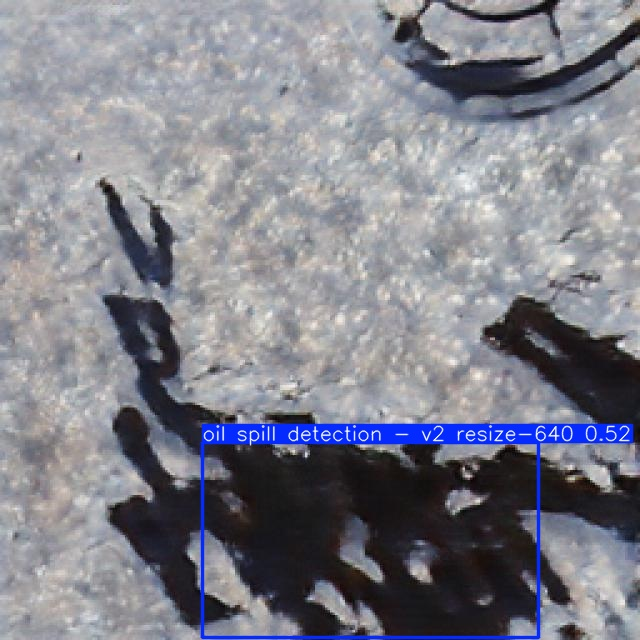

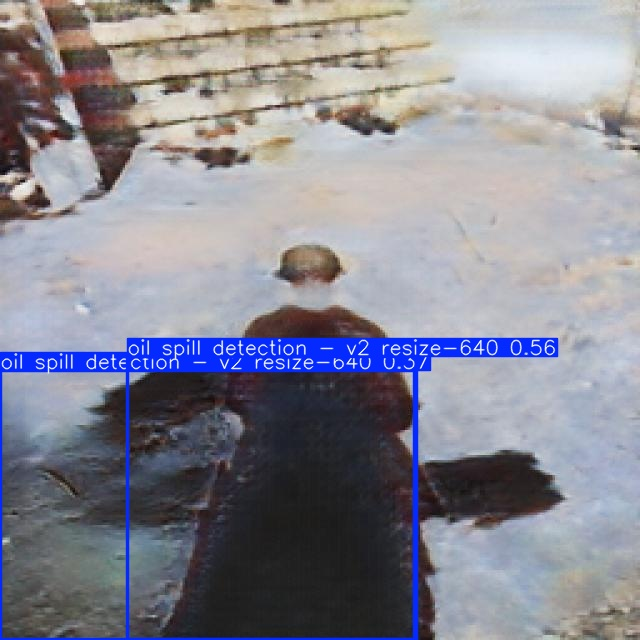

In [21]:
import os
import glob
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Dynamically get the exact directory where YOLO saved the predictions
if predict_results:
    save_dir = predict_results[0].save_dir
    predicted_images = glob.glob(os.path.join(save_dir, '*.jpg'))
    
    print(f"Found {len(predicted_images)} images in {save_dir}")
    
    # Display the first 3 predicted images
    for img_path in predicted_images[:3]:
        display(Image(filename=img_path, width=600))
else:
    print("No prediction results were generated.")

In [22]:
from IPython.display import FileLink
import os

# YOLOv8 saves the best weights automatically
model_path = '/kaggle/working/runs/oil_spill_model/weights/best.pt'

if os.path.exists(model_path):
    print("Click the link below to download your trained model:")
    display(FileLink(model_path))
else:
    print("Model not found. Please ensure training completed successfully.")

Click the link below to download your trained model:


/kaggle/working/runs/oil_spill_model/weights/best.pt

In [23]:
import os
import glob
import ipywidgets as widgets
from IPython.display import display, Image as IPyImage, clear_output
from ultralytics import YOLO

# Create an upload button widget and an output area
print("Please upload an image to test your model:")
upload_widget = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()

display(upload_widget, output)

def on_upload_change(change):
    # Route all output to the Output widget so it renders correctly in notebook
    with output:
        clear_output(wait=True)
        if upload_widget.value:
            # Handle ipywidgets standard across versions 7 and 8
            if isinstance(upload_widget.value, tuple):
                uploaded_file = upload_widget.value[0]
                uploaded_filename = uploaded_file['name']
                uploaded_content = uploaded_file['content']
            else:
                uploaded_filename = list(upload_widget.value.keys())[0]
                uploaded_content = upload_widget.value[uploaded_filename]['content']
                
            # Save it temporarily to Kaggle working directory
            temp_img_path = f'/kaggle/working/{uploaded_filename}'
            with open(temp_img_path, 'wb') as f:
                f.write(uploaded_content)
            
            print(f"\\nProcessing: {uploaded_filename}...")
            
            # Load the best trained model
            best_model = YOLO('/kaggle/working/runs/oil_spill_model/weights/best.pt')
            
            # Make a prediction
            custom_results = best_model.predict(source=temp_img_path, save=True, conf=0.25)
            
            # Display the result
            if custom_results:
                save_dir = custom_results[0].save_dir
                
                # Dynamically locate the saved image (fixes issues where YOLO modifies extensions or filenames)
                predicted_files = glob.glob(os.path.join(save_dir, '*.*'))
                
                if predicted_files:
                    result_img_path = predicted_files[0]
                    print("\\nPrediction Result:")
                    display(IPyImage(filename=result_img_path, width=600))
                else:
                    print("Error: Could not find the generated prediction image.")

# Attach the event listener to the widget
upload_widget.observe(on_upload_change, names='value')

Please upload an image to test your model:


FileUpload(value=(), accept='image/*', description='Upload')

Output()